# **1 – Introduction**



# Feature Scaling - Beginner Guide

In this notebook you will learn:

✅ What is Feature Scaling

✅ Why Feature Scaling is Important

✅ Problems Without Scaling

✅ StandardScaler

✅ How Scaling Works

✅ Mean and Standard Deviation

✅ Before vs After Scaling

Target Audience:

- Beginners
- Data Analyst Aspirants
- Data Science Learners

# **2 – Real Life Example**

# Why Do We Need Feature Scaling?

Imagine we have information about cars.

Weight = 3500

Horsepower = 120

Acceleration = 15

Notice that **Weight** is much larger than the other values.

Machine Learning algorithms may think Weight is more important simply because its values are bigger.

Feature Scaling solves this problem by bringing all features to a similar scale.

# **3 – Setting up the data**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


In [13]:
numeric_columns = ['displacement', 'horsepower', 'weight', 'acceleration']
car_data[numeric_columns].head()

,displacement,horsepower,weight,acceleration
0,307.0,130.0,3504.0,12.0
1,350.0,165.0,3693.0,11.5
2,318.0,150.0,3436.0,11.0
3,304.0,150.0,3433.0,12.0
4,302.0,140.0,3449.0,10.5


In [14]:
car_data[numeric_columns].describe()

,displacement,horsepower,weight,acceleration
count,398.000000,398.000000,398.000000,398.000000
mean,193.425879,104.469388,2970.424623,15.568090
std,104.269838,38.199187,846.841774,2.757689
min,68.000000,46.000000,1613.000000,8.000000
25%,104.250000,76.000000,2223.750000,13.825000
50%,148.500000,95.000000,2803.500000,15.500000
75%,262.000000,125.000000,3608.000000,17.175000
max,455.000000,230.000000,5140.000000,24.800000


# **4 – Before Scaling Example**

## Before Scaling

| Feature | Value |
|----------|--------|
| Weight | 3500 |
| Horsepower | 120 |
| Acceleration | 15 |

Weight dominates because it has much larger values.

# **5 – Import StandardScaler**

StandardScaler is used to standardize numerical features.

In [15]:
from sklearn.preprocessing import StandardScaler

# **6 – Create Scaler**

Create a StandardScaler object.

This object will learn the mean and standard deviation of each column.

In [16]:
standardscaler = StandardScaler()

# **7 – Apply Scaling**

In [17]:
scaled_features = standardscaler.fit_transform(
                      car_data[numeric_columns]
                  ).round(3)
scaled_features

array([[ 1.091,  0.669,  0.631, -1.295],
       [ 1.504,  1.587,  0.854, -1.477],
       [ 1.196,  1.193,  0.55 , -1.659],
       ...,
       [-0.561, -0.537, -0.799, -1.441],
       [-0.705, -0.668, -0.408,  1.101],
       [-0.715, -0.589, -0.296,  1.391]])

# **8 – What Does fit_transform() Do?**

fit()

Calculates:

- Mean
- Standard Deviation

for each column.

transform()

- Uses those values to scale the data.

fit_transform()

- Performs both operations together.

# **9 – Convert to DataFrame**

In [18]:
scaled_car_data = pd.DataFrame(
    scaled_features,
    columns=numeric_columns
    )
scaled_car_data.head()

,displacement,horsepower,weight,acceleration
0,1.091,0.669,0.631,-1.295
1,1.504,1.587,0.854,-1.477
2,1.196,1.193,0.550,-1.659
3,1.062,1.193,0.547,-1.295
4,1.043,0.931,0.566,-1.840


# **10 – Check Statistics After Scaling**

Notice:

Mean ≈ 0

Standard Deviation ≈ 1

This is the goal of StandardScaler.

In [19]:
scaled_car_data.describe()

,displacement,horsepower,weight,acceleration
count,398.000000,398.000000,398.000000,398.000000
mean,0.000045,0.000005,0.000003,0.000013
std,1.001294,1.001222,1.001265,1.001271
min,-1.204000,-1.533000,-1.605000,-2.748000
25%,-0.856500,-0.746000,-0.883000,-0.633000
50%,-0.431000,-0.248000,-0.197500,-0.025000
75%,0.658000,0.538000,0.753750,0.583750
max,2.512000,3.290000,2.565000,3.352000


# **11 – Understanding the Formula**

StandardScaler Formula

**Scaled Value = (Value - Mean) / Standard Deviation**

Example:

- Weight = 3504.0 (Weight of the 1st Car)

- Mean Weight = 2970.424623

- Std Weight = 846.841774

Scaled Weight

= (3504.0 - 2970.424623) / 846.841774

= 0.63

# **12 - Visual Comparison**

**a. Before Scaling**

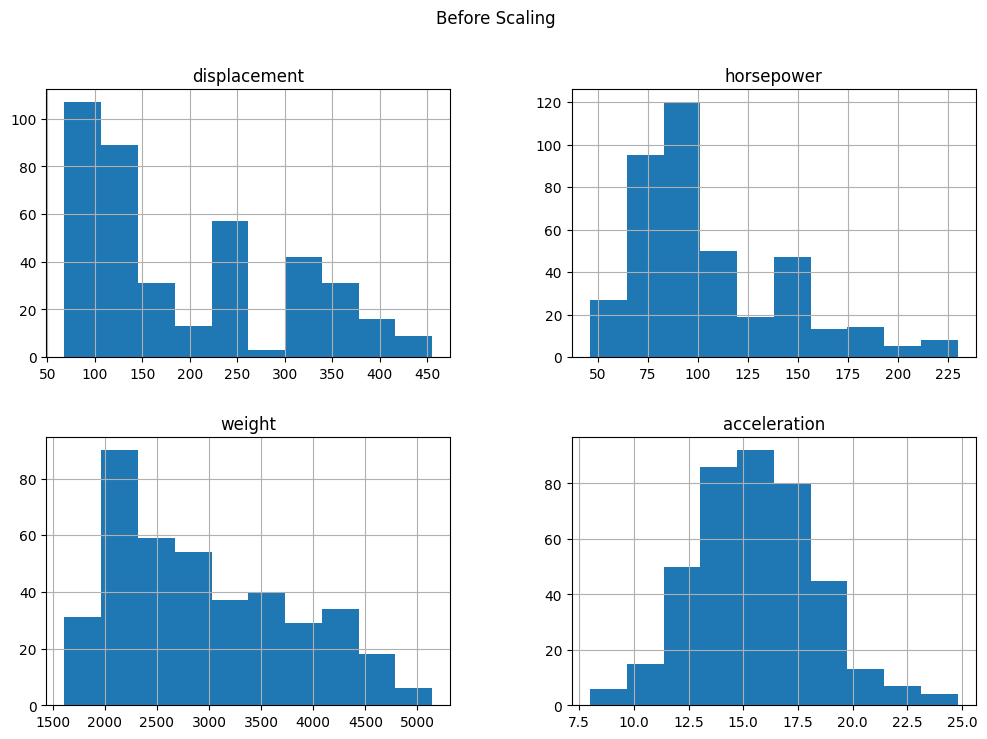

In [20]:
import matplotlib.pyplot as plt

car_data[numeric_columns].hist(
    figsize = (12, 8)
)

plt.suptitle("Before Scaling")
plt.show()

**b. After Scaling**

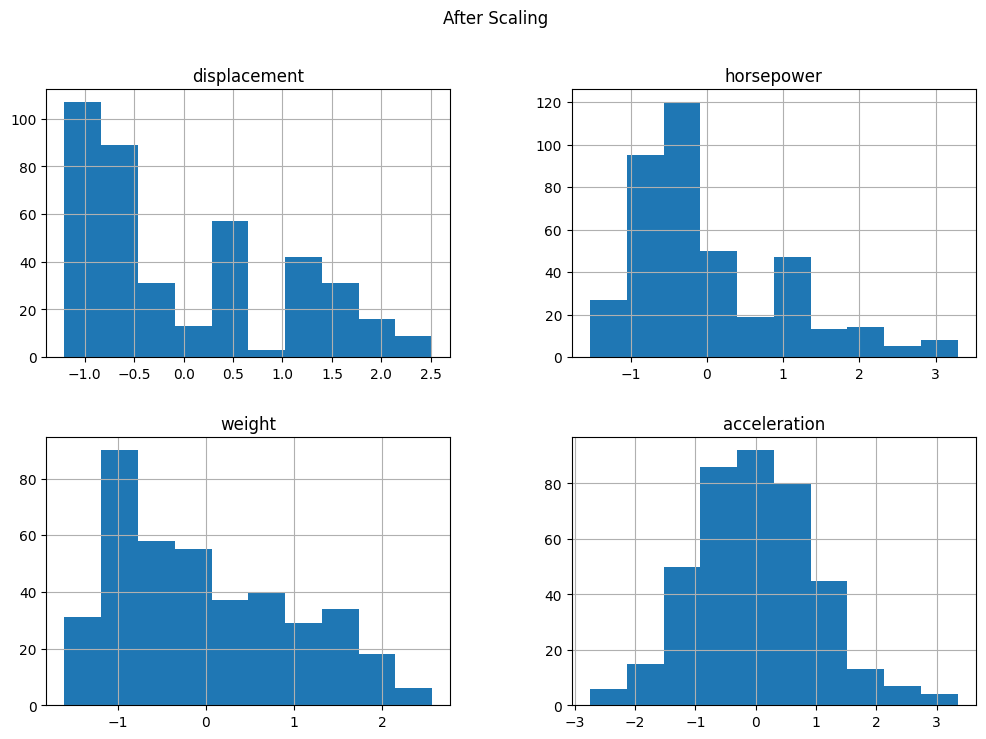

In [21]:
scaled_car_data.hist(
    figsize = (12, 8)
)

plt.suptitle("After Scaling")
plt.show()

# **13 – Key Observations**

**Before Scaling:**

- Weight values were much larger.

**After Scaling:**

- All features are on a similar scale.

This helps Machine Learning algorithms perform better.

# **14 – Practice Exercises**

# Practice Exercises

Exercise 1

Find the mean of each column before scaling.

--------------------------------

Exercise 2

Find the standard deviation of each column before scaling.

--------------------------------

Exercise 3

Apply StandardScaler.

--------------------------------

Exercise 4

Verify that the mean is close to 0.

--------------------------------

Exercise 5

Verify that the standard deviation is close to 1.

--------------------------------

Exercise 6

Compare the histograms before and after scaling.

In [22]:
car_data[numeric_columns].mean()

,0
displacement,193.425879
horsepower,104.469388
weight,2970.424623
acceleration,15.568090


In [23]:
car_data[numeric_columns].std()

,0
displacement,104.269838
horsepower,38.199187
weight,846.841774
acceleration,2.757689


In [24]:
standardscaler = StandardScaler()

scaled_features = standardscaler.fit_transform(
                      car_data[numeric_columns]
                  ).round(3)

scaled_features

array([[ 1.091,  0.669,  0.631, -1.295],
       [ 1.504,  1.587,  0.854, -1.477],
       [ 1.196,  1.193,  0.55 , -1.659],
       ...,
       [-0.561, -0.537, -0.799, -1.441],
       [-0.705, -0.668, -0.408,  1.101],
       [-0.715, -0.589, -0.296,  1.391]])

In [25]:
scaled_car_data = pd.DataFrame(
    scaled_features,
    columns=numeric_columns
    )
scaled_car_data.mean()

,0
displacement,0.000045
horsepower,0.000005
weight,0.000003
acceleration,0.000013


In [26]:
scaled_car_data.std()

,0
displacement,1.001294
horsepower,1.001222
weight,1.001265
acceleration,1.001271


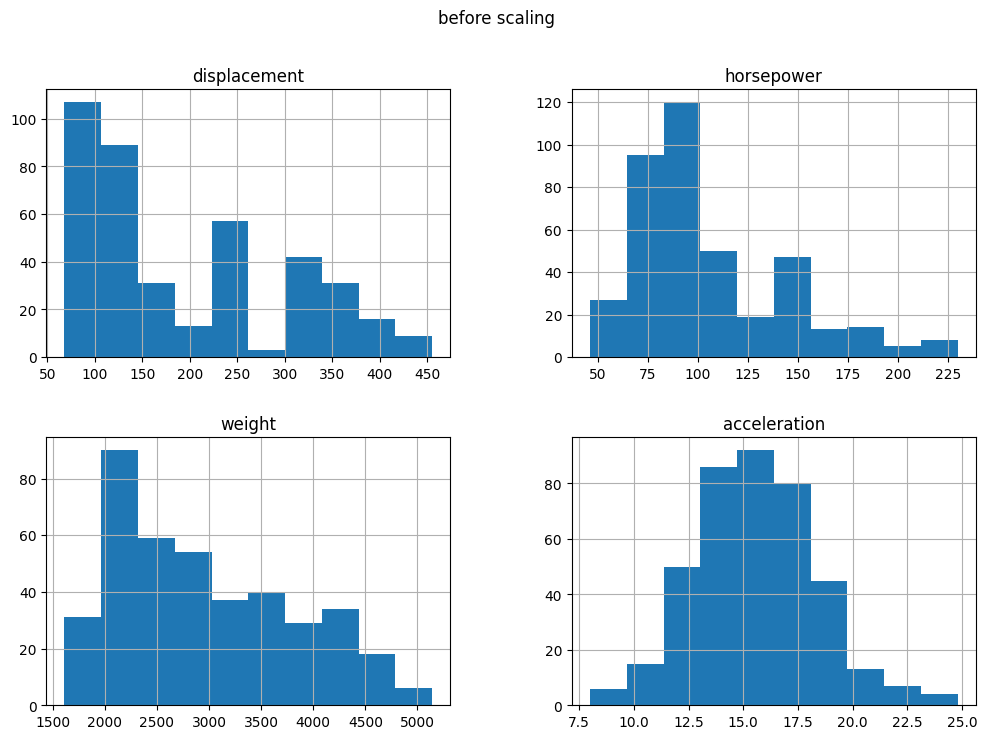

In [27]:
car_data[numeric_columns].hist(
    figsize=(12,8)
)

plt.suptitle('before scaling')
plt.show()

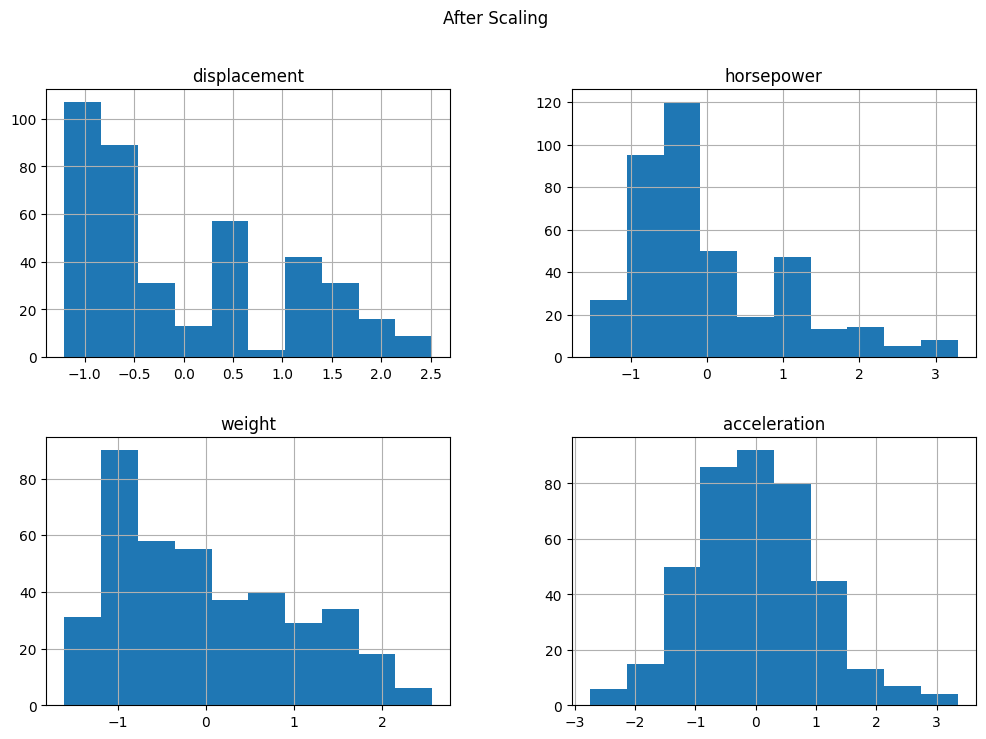

In [28]:
scaled_car_data[numeric_columns].hist(
    figsize=(12,8)
)

plt.suptitle('After Scaling')
plt.show()

# **15 - Interview Questions**

  1. What is Feature Scaling?

  2. Why is Feature Scaling important?

  3. Which algorithms require scaling?

  4. What is StandardScaler?

  5. What does fit() do?

  6. What does transform() do?

  7. What does fit_transform() do?

  8. What is the formula used by StandardScaler?

  9. What should be the mean after scaling?

  10. What should be the standard deviation after scaling?

# **16 – Summary**

# What You Learned

✅ Feature Scaling

✅ StandardScaler

✅ Mean

✅ Standard Deviation

✅ fit()

✅ transform()

✅ fit_transform()

✅ Before vs After Scaling

Next Notebook:

04_PCA_Beginner_Guide.ipynb